In [41]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [42]:
#Зчитуємо файли
df = pd.read_csv('ab_test_data.csv',encoding='utf=8')

In [43]:
df.head

<bound method NDFrame.head of                                     user_id                   timestamp  \
0      7f6833e6-1141-4f20-b4b2-f1e31019b1fd  2023-07-04 04:40:55.848109   
1      e6a6e960-d3f3-4074-a516-ba1e609b211e  2023-07-06 00:26:45.486187   
2      4d3fbfa5-6847-410a-bac2-477f01d5f400  2023-07-10 20:24:33.639464   
3      361457d9-a044-48f7-981c-d67dc3861679  2023-07-20 07:04:49.957013   
4      285cd63d-7d03-427f-a062-1fa2dd2e77d6  2023-07-19 23:27:50.116680   
...                                     ...                         ...   
19993  6763ae9a-515c-473e-af00-0d9c4f6a5bc7  2023-07-06 03:27:37.041104   
19994  ac5600f2-4d16-4503-b115-f1a96728b6d1  2023-07-03 04:20:48.572143   
19995  5a8b2630-209b-4d83-b47f-0f3d9dd568a8  2023-07-23 16:23:49.211910   
19996  b572d68b-26ac-432b-9f88-83e0fdee4ca1  2023-07-03 18:26:20.880675   
19997  3d313adc-c8d6-43f2-8b4e-e267b194ff78  2023-07-19 13:15:37.562340   

      test_group  conversion  
0              a           0  
1      

In [44]:
df.info

<bound method DataFrame.info of                                     user_id                   timestamp  \
0      7f6833e6-1141-4f20-b4b2-f1e31019b1fd  2023-07-04 04:40:55.848109   
1      e6a6e960-d3f3-4074-a516-ba1e609b211e  2023-07-06 00:26:45.486187   
2      4d3fbfa5-6847-410a-bac2-477f01d5f400  2023-07-10 20:24:33.639464   
3      361457d9-a044-48f7-981c-d67dc3861679  2023-07-20 07:04:49.957013   
4      285cd63d-7d03-427f-a062-1fa2dd2e77d6  2023-07-19 23:27:50.116680   
...                                     ...                         ...   
19993  6763ae9a-515c-473e-af00-0d9c4f6a5bc7  2023-07-06 03:27:37.041104   
19994  ac5600f2-4d16-4503-b115-f1a96728b6d1  2023-07-03 04:20:48.572143   
19995  5a8b2630-209b-4d83-b47f-0f3d9dd568a8  2023-07-23 16:23:49.211910   
19996  b572d68b-26ac-432b-9f88-83e0fdee4ca1  2023-07-03 18:26:20.880675   
19997  3d313adc-c8d6-43f2-8b4e-e267b194ff78  2023-07-19 13:15:37.562340   

      test_group  conversion  
0              a           0  
1    

In [45]:
# Кількість користувачів
users_count = df.groupby('test_group')['user_id'].count()
print("Users count:", users_count)

Users count: test_group
a    10013
b     9985
Name: user_id, dtype: int64


In [46]:
# Кількість конверсій
conversions = df.groupby('test_group')['conversion'].sum()
print("\Conversions:", conversions)

\Conversions: test_group
a    611
b    889
Name: conversion, dtype: int64


In [47]:
# Рівень конверсії
conversion_rate = df.groupby('test_group')['conversion'].mean()
print("Conversion rate:", conversion_rate)

Conversion rate: test_group
a    0.061021
b    0.089034
Name: conversion, dtype: float64


In [48]:
# Перетворення в datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Початок і кінець тесту
start_date = df['timestamp'].min()
end_date = df['timestamp'].max()

# Тривалість
duration = (end_date - start_date).days

print("\nStart date:", start_date)
print("End date:", end_date)
print("Duration (days):", duration)


Start date: 2023-07-03 01:42:34.033708
End date: 2023-07-25 01:41:19.152664
Duration (days): 21


In [49]:
group_a = df[df['test_group'] == 'a']['conversion']
group_b = df[df['test_group'] == 'b']['conversion']

stat, p_value = ttest_ind(group_a, group_b, equal_var=False)

print("t-statistic:", stat)
print("p-value:", p_value)


t-statistic: -7.528139567322235
p-value: 5.371629545263574e-14


In [50]:
alpha = 0.05

if p_value < alpha:
    print("Відхиляємо H0 — різниця статистично значуща")
else:
    print("Не можемо відхилити H0 — різниця незначуща")

Відхиляємо H0 — різниця статистично значуща


Для перевірки гіпотези було використано t-test для незалежних вибірок.

Нульова гіпотеза:
середній рівень конверсії в групах A та B однаковий.

Альтернативна гіпотеза:
середні значення відрізняються.

За результатами тесту:

t-статистика: t = -7.53
p-value: 5.37e-14

Оскільки p-value значно менше рівня значущості α = 0.05, нульову гіпотезу відхиляємо.

Висновок:
Існує статистично значуща різниця між групами.
Рівень конверсії в групі B є вищим, ніж у групі A.

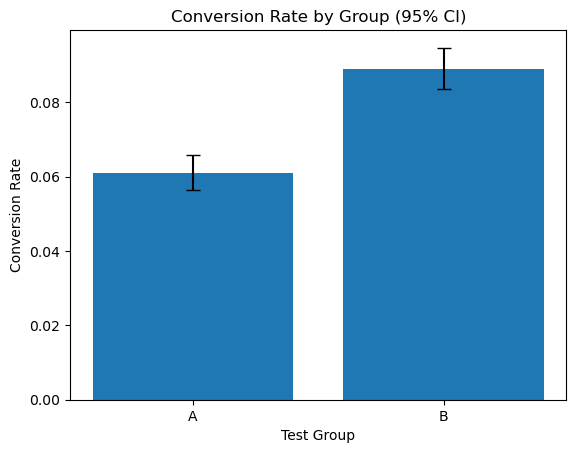

In [57]:
# групи
group_a = df[df['test_group'] == 'a']['conversion']
group_b = df[df['test_group'] == 'b']['conversion']

# середні
mean_a = group_a.mean()
mean_b = group_b.mean()

# стандартна похибка (SEM)
sem_a = group_a.std(ddof=1) / np.sqrt(len(group_a))
sem_b = group_b.std(ddof=1) / np.sqrt(len(group_b))

# 95% довірчий інтервал (≈ 1.96 * SEM)
ci_a = 1.96 * sem_a
ci_b = 1.96 * sem_b

means = [mean_a, mean_b]
errors = [ci_a, ci_b]
labels = ['A', 'B']

plt.figure()
plt.bar(labels, means, yerr=errors, capsize=5)

plt.title('Conversion Rate by Group (95% CI)')
plt.ylabel('Conversion Rate')
plt.xlabel('Test Group')
plt.savefig('chart.png', dpi=300, bbox_inches='tight')
plt.show()


In [52]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date

In [53]:
daily_cr = df.groupby(['date', 'test_group'])['conversion'].mean().reset_index()

In [54]:
pivot_df = daily_cr.pivot(index='date', columns='test_group', values='conversion')

<Figure size 640x480 with 0 Axes>

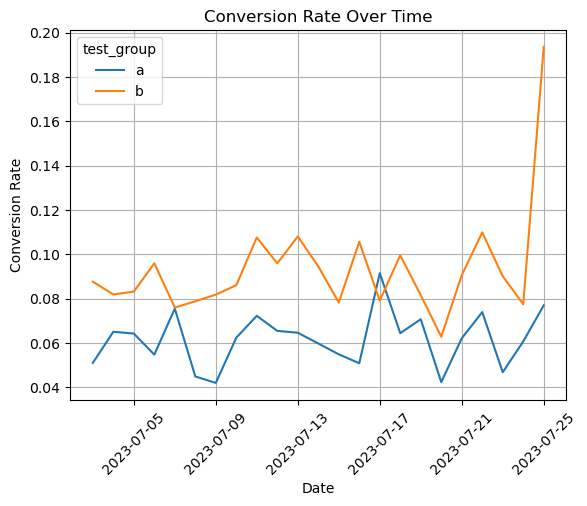

In [58]:
plt.figure()

pivot_df.plot()

plt.title('Conversion Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Conversion Rate')

plt.xticks(rotation=45)
plt.grid()
plt.savefig('chart2.png', dpi=300, bbox_inches='tight')
plt.show()